# LLM Sokoban Agent 비교 실험

> 저장 출력은 LangGraph 전환 전 기준선이다. 입력 코드는 새 Planner API로 갱신했으며 Ollama 재실행 후 결과를 비교한다.

## tl;dr

- 저장된 `gemma4:26b` 실행은 동일한 3개 레벨 × 2개 seed 중 2/6 에피소드(33%)를 해결했다. 성공은 `tiny-push` 2회였다.
- BFS는 6/6, Random은 0/6을 해결했다.
- LLM은 총 88회 호출했고 30회 재시도했으며, Python 검증기가 막힌 행동 32회를 환경 실행 전에 거절했다.
- 아래 애니메이션은 집계에 사용된 실제 LLM 에피소드의 보드와 실행 행동을 순서대로 재생한다.
- 이 수치는 아래 고정 설정으로 저장된 실행 결과이며, 모델이나 설정을 바꾸면 다시 실행해 갱신해야 한다.

## Context & Methods

상태 배열을 표준 Sokoban 문자 보드로 직렬화하고, 모델에는 `{"action":"UP"}` 형태의 JSON Schema 출력을 요구한다. LangGraph가 응답 형식, 이동 가능 여부와 재시도 흐름을 검증·실행한다.

### Key Assumptions

- `.env`의 Ollama 서버와 모델이 실행 시점에 사용 가능하다.
- `temperature=0`과 episode seed를 모델 호출에 전달하지만, 런타임·모델 버전에 따라 완전한 결정성은 보장되지 않는다.
- `heldout-turn`은 제품 기본 레벨에 포함하지 않은 실험용 소형 레벨이다.
- 실행 시간은 로컬/원격 Ollama 상태의 영향을 받는다.

### 1. Load dependencies and fixed parameters

In [1]:
from dataclasses import asdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, Markdown, display
from matplotlib import animation

from sokoban_agent.env import (
    DEFAULT_LEVELS,
    FixedLevelProvider,
    SokobanEnv,
    parse_level,
)
from sokoban_agent.evaluation import (
    run_benchmark_traces,
    summarize_by_planner,
)
from sokoban_agent.planning import (
    BFSPlanner,
    LLMPlanner,
    RandomPlanner,
    SearchGuardPlanner,
)
from sokoban_agent.planning.llm import OllamaClient, OllamaSettings

LEVEL_IDS = ['tiny-push', 'tiny-walk', 'heldout-turn']
SEEDS = [0, 1]
MAX_STEPS = 15
MAX_ATTEMPTS = 3

settings = OllamaSettings.from_env()
experiment_config = {
    'model': settings.model,
    'temperature': settings.temperature,
    'level_ids': LEVEL_IDS,
    'seeds': SEEDS,
    'max_steps': MAX_STEPS,
    'max_planning_attempts': MAX_ATTEMPTS,
}
experiment_config

{'model': 'gemma4:26b',
 'temperature': 0.0,
 'level_ids': ['tiny-push', 'tiny-walk', 'heldout-turn'],
 'seeds': [0, 1],
 'max_steps': 15,
 'max_planning_attempts': 3}

## Data

### 2. Build the fixed and held-out level cohort

In [2]:
heldout_level = parse_level(
    'heldout-turn',
    [
        '#####',
        '#.  #',
        '# $ #',
        '#  @#',
        '#####',
    ],
)
level_provider = FixedLevelProvider(
    [
        DEFAULT_LEVELS.get('tiny-push'),
        DEFAULT_LEVELS.get('tiny-walk'),
        heldout_level,
    ]
)
LEVEL_IDS

['tiny-push', 'tiny-walk', 'heldout-turn']

### 3. Run identical cases

In [3]:
client = OllamaClient(settings)
planners = [
    RandomPlanner(),
    BFSPlanner(),
    LLMPlanner(
        client,
        model_name=settings.model,
    ),
    SearchGuardPlanner(
        LLMPlanner(client, model_name=settings.model)
    ),
]
env = SokobanEnv(
    level_provider=level_provider,
    max_steps=MAX_STEPS,
)
try:
    traces = run_benchmark_traces(
        env,
        planners,
        level_ids=LEVEL_IDS,
        seeds=SEEDS,
        max_planning_attempts=MAX_ATTEMPTS,
    )
finally:
    env.close()

results = [trace.result for trace in traces]
results_df = pd.DataFrame.from_records(
    asdict(result) for result in results
)
results_df

,planner_name,level_id,seed,success,deadlock,truncated,action_count,invalid_moves,total_reward,elapsed_seconds,failure_reason,llm_calls,llm_retries,llm_client_errors,llm_format_errors,llm_invalid_actions,llm_elapsed_seconds
0,random,tiny-push,0,False,False,True,15,6,-1.5,0.000414,NaN,0,0,0,0,0,0.000000
1,random,tiny-push,1,False,False,True,15,4,-1.5,0.000101,NaN,0,0,0,0,0,0.000000
2,random,tiny-walk,0,False,False,True,15,7,-1.5,0.000099,NaN,0,0,0,0,0,0.000000
3,random,tiny-walk,1,False,False,True,15,5,-1.5,0.000094,NaN,0,0,0,0,0,0.000000
4,random,heldout-turn,0,False,False,True,15,7,-1.5,0.000100,NaN,0,0,0,0,0,0.000000
5,random,heldout-turn,1,False,False,True,15,5,-1.5,0.000102,NaN,0,0,0,0,0,0.000000
6,bfs,tiny-push,0,True,False,False,1,0,10.9,0.000039,NaN,0,0,0,0,0,0.000000
7,bfs,tiny-push,1,True,False,False,1,0,10.9,0.000028,NaN,0,0,0,0,0,0.000000
8,bfs,tiny-walk,0,True,False,False,5,0,10.5,0.000123,NaN,0,0,0,0,0,0.000000
9,bfs,tiny-walk,1,True,False,False,5,0,10.5,0.000113,NaN,0,0,0,0,0,0.000000


## Results

### 4. Compare success, efficiency, recovery, and latency

In [4]:
summary_df = pd.DataFrame.from_records(
    asdict(summary) for summary in summarize_by_planner(results)
).set_index('planner_name')
summary_columns = [
    'episode_count',
    'success_count',
    'success_rate',
    'mean_actions',
    'mean_actions_on_success',
    'mean_elapsed_seconds',
    'total_algorithm_calls',
    'total_algorithm_fallbacks',
    'total_llm_calls',
    'total_llm_retries',
    'total_llm_format_errors',
    'total_llm_invalid_actions',
    'mean_llm_elapsed_seconds',
]
summary_df[summary_columns]

,episode_count,success_count,success_rate,mean_actions,mean_actions_on_success,mean_elapsed_seconds,total_llm_calls,total_llm_retries,total_llm_format_errors,total_llm_invalid_actions,mean_llm_elapsed_seconds
planner_name,,,,,,,,,,,
random,6,0,0.000000,15.000000,NaN,0.000152,0,0,0,0,0.000000
bfs,6,6,1.000000,3.666667,3.666667,0.000087,0,0,0,0,0.000000
llm:gemma4:26b,6,2,0.333333,9.333333,1.000000,12.027536,88,30,0,32,12.022103


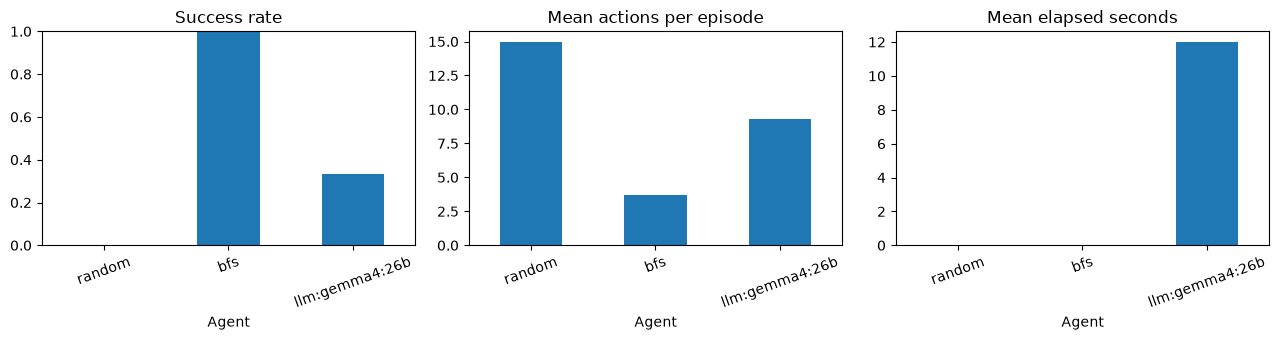

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
summary_df['success_rate'].plot.bar(
    ax=axes[0], ylim=(0, 1), title='Success rate'
)
summary_df['mean_actions'].plot.bar(
    ax=axes[1], title='Mean actions per episode'
)
summary_df['mean_elapsed_seconds'].plot.bar(
    ax=axes[2], title='Mean elapsed seconds'
)
for axis in axes:
    axis.set_xlabel('Agent')
    axis.tick_params(axis='x', rotation=20)
fig.tight_layout()
plt.show()

### 5. Inspect LLM failures by level and seed

In [6]:
llm_name = f'graph:llm:{settings.model}'
llm_columns = [
    'level_id',
    'seed',
    'success',
    'deadlock',
    'truncated',
    'action_count',
    'llm_calls',
    'llm_retries',
    'llm_client_errors',
    'llm_format_errors',
    'llm_invalid_actions',
    'llm_elapsed_seconds',
    'failure_reason',
]
llm_results_df = results_df[
    results_df['planner_name'] == llm_name
][llm_columns]
llm_results_df

,level_id,seed,success,deadlock,truncated,action_count,llm_calls,llm_retries,llm_client_errors,llm_format_errors,llm_invalid_actions,llm_elapsed_seconds,failure_reason
12,tiny-push,0,True,False,False,1,1,0,0,0,0,1.195886,NaN
13,tiny-push,1,True,False,False,1,1,0,0,0,0,0.609748,NaN
14,tiny-walk,0,False,False,True,15,23,8,0,0,8,18.217641,NaN
15,tiny-walk,1,False,False,True,15,23,8,0,0,8,18.584428,NaN
16,heldout-turn,0,False,False,False,12,20,7,0,0,8,17.831945,LLM failed to return a legal action after 3 at...
17,heldout-turn,1,False,False,False,12,20,7,0,0,8,15.692971,LLM failed to return a legal action after 3 at...


### 6. Replay exact agent movement

기본 선택은 장기 계획 실패가 드러나는 LLM의 `tiny-walk`, seed 0 에피소드다. `ANIMATION_CASE`를 바꾸면 같은 실험의 Random이나 BFS 경로도 재생할 수 있다. 표와 영상에는 환경이 실제로 실행한 행동만 포함된다.

In [7]:
ANIMATION_CASE = {
    'planner_name': llm_name,
    'level_id': 'tiny-walk',
    'seed': 0,
}
selected_trace = next(
    trace
    for trace in traces
    if trace.result.planner_name == ANIMATION_CASE['planner_name']
    and trace.result.level_id == ANIMATION_CASE['level_id']
    and trace.result.seed == ANIMATION_CASE['seed']
)

action_log_df = pd.DataFrame.from_records(
    {
        'frame': frame.index,
        'action': (
            frame.action.name
            if frame.action is not None
            else 'RESET'
        ),
        'invalid_move': frame.invalid_move,
        'pushed': frame.pushed,
        'success': frame.success,
        'deadlock': frame.deadlock,
    }
    for frame in selected_trace.frames
)
action_log_df

,frame,action,invalid_move,pushed,success,deadlock
0,0,RESET,False,False,False,False
1,1,UP,False,False,False,False
2,2,DOWN,False,False,False,False
3,3,UP,False,False,False,False
4,4,UP,False,False,False,False
5,5,DOWN,False,False,False,False
6,6,UP,False,False,False,False
7,7,DOWN,False,False,False,False
8,8,UP,False,False,False,False
9,9,DOWN,False,False,False,False


In [8]:
RGB_PALETTE = np.asarray(
    [
        [238, 238, 238],  # floor
        [45, 45, 45],     # wall
        [255, 196, 64],   # target
        [139, 90, 43],    # box
        [55, 126, 184],   # player
        [76, 175, 80],    # box on target
        [126, 87, 194],   # player on target
    ],
    dtype=np.uint8,
)

def animate_episode_trace(trace, interval_ms=700):
    fig, axis = plt.subplots(figsize=(4.5, 4.5))
    image = axis.imshow(
        RGB_PALETTE[trace.frames[0].observation]
    )
    axis.set_xticks([])
    axis.set_yticks([])
    title = axis.set_title('')

    def update(frame_index):
        frame = trace.frames[frame_index]
        image.set_data(RGB_PALETTE[frame.observation])
        action_name = (
            frame.action.name
            if frame.action is not None
            else 'RESET'
        )
        if frame.success:
            status = 'SUCCESS'
        elif frame.deadlock:
            status = 'DEADLOCK'
        elif frame_index == len(trace.frames) - 1:
            status = (
                'STEP LIMIT'
                if trace.result.truncated
                else 'STOPPED'
            )
        else:
            status = 'RUNNING'
        title.set_text(
            f"{trace.result.planner_name} | "
            f"{trace.result.level_id} | "
            f"frame {frame.index} | {action_name} | {status}"
        )
        return image, title

    episode_animation = animation.FuncAnimation(
        fig,
        update,
        frames=len(trace.frames),
        interval=interval_ms,
        repeat=True,
        blit=False,
    )
    html = episode_animation.to_jshtml(default_mode='loop')
    plt.close(fig)
    return HTML(html)

display(animate_episode_trace(selected_trace))

### 7. Validate the comparison cohort

In [9]:
case_sets = {
    planner_name: set(
        zip(group['level_id'], group['seed'], strict=True)
    )
    for planner_name, group in results_df.groupby('planner_name')
}
expected_cases = set(
    (level_id, seed)
    for level_id in LEVEL_IDS
    for seed in SEEDS
)
assert all(cases == expected_cases for cases in case_sets.values())
assert summary_df.loc['graph:bfs', 'success_rate'] == 1.0
assert summary_df.loc[llm_name, 'total_llm_client_errors'] == 0
assert len(selected_trace.frames) == (
    selected_trace.result.action_count + 1
)
assert action_log_df['action'].eq('RESET').sum() == 1
{name: len(cases) for name, cases in case_sets.items()}

{'bfs': 6, 'llm:gemma4:26b': 6, 'random': 6}

## Takeaways

In [10]:
llm_summary = summary_df.loc[llm_name]
bfs_summary = summary_df.loc['graph:bfs']
solved_levels = llm_results_df.loc[
    llm_results_df['success'], 'level_id'
].value_counts().to_dict()
display(Markdown(
    f'- LLM은 {int(llm_summary.success_count)}/'
    f'{int(llm_summary.episode_count)} 에피소드를 해결했다 '
    f'({llm_summary.success_rate:.0%}).\n'
    f'- BFS는 같은 cohort에서 '
    f'{bfs_summary.success_rate:.0%} 성공했다.\n'
    f'- LLM의 총 호출은 {int(llm_summary.total_llm_calls)}회, '
    f'재시도는 {int(llm_summary.total_llm_retries)}회, '
    f'막힌 행동 거절은 '
    f'{int(llm_summary.total_llm_invalid_actions)}회였다.\n'
    f'- 성공 레벨별 횟수: `{solved_levels}`. 이 결과는 소형 '
    '3개 레벨의 탐색 실험이며 전체 Boxoban 성능을 대표하지 않는다.'
))

- LLM은 2/6 에피소드를 해결했다 (33%).
- BFS는 같은 cohort에서 100% 성공했다.
- LLM의 총 호출은 88회, 재시도는 30회, 막힌 행동 거절은 32회였다.
- 성공 레벨별 횟수: `{'tiny-push': 2}`. 이 결과는 소형 3개 레벨의 탐색 실험이며 전체 Boxoban 성능을 대표하지 않는다.